# Unemployment Analysis with Python
### Objective
To analyze unemployment data in India and identify regional, monthly, and COVID-19 related trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importing and Understanding the Dataset

The dataset contains unemployment-related information for different regions of India over time.

In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Dataset Overview

## 3.1 Shape and Structure

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (267, 9)


## 3.2 Column Names and Data Types

In [4]:
print("Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Column Names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

Data Types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                        str
longitude                                   float64
latitude                                    float64
dtype: object


## 3.3 Missing Values

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


## 3.4 Descriptive Statistics

In [6]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [7]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


## 4. Data Cleaning and Type Conversion

### 4.1 Cleaning Column Names

In [8]:
df.columns = df.columns.str.strip()

print("Cleaned Column Names:")
print(df.columns)

Cleaned Column Names:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


## 4.2 Convert Date Column

In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Date column converted successfully.")
print(df['Date'].head())
print("\nData type:", df['Date'].dtype)

Date column converted successfully.
0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[us]

Data type: datetime64[us]


## 4.3 — Check Missing Values After Cleaning

In [10]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


## 5. Exploratory Data Analysis

### 5.1 Region-wise Average Unemployment Rate

In [11]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print("Average Unemployment Rate by Region:")
print(region_avg)

Average Unemployment Rate by Region:
Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64


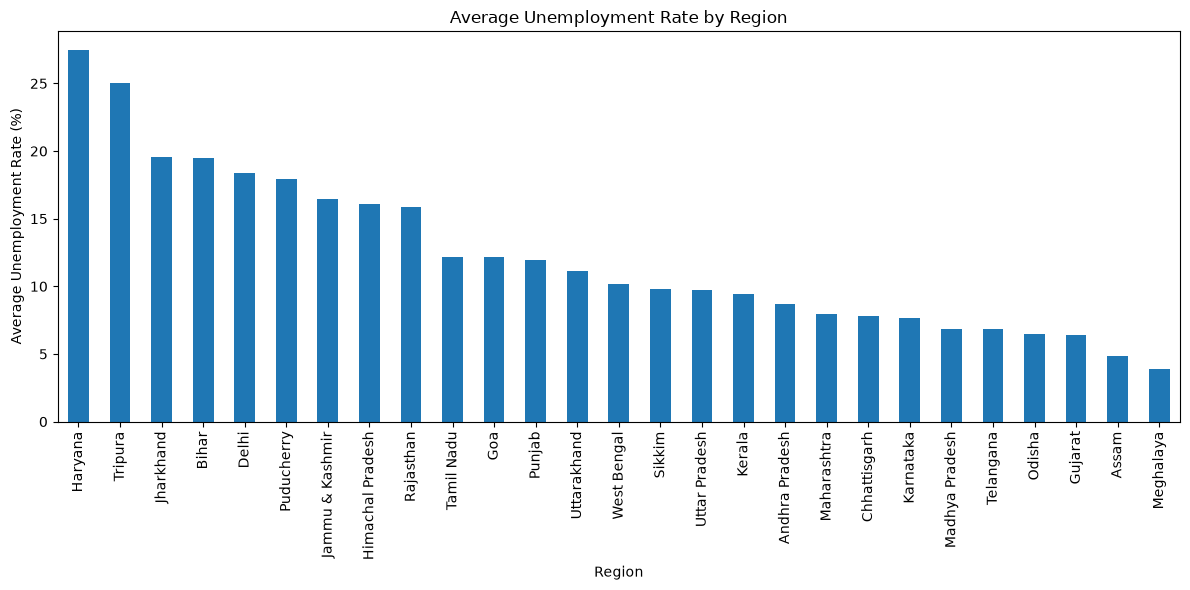

In [12]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observation

The bar chart shows the average unemployment rate across different regions.
It helps us compare unemployment levels and understand the variation in
unemployment conditions across different regions of India.

## 5.2 Month-wise Unemployment Trend.

In [13]:
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))[
    'Estimated Unemployment Rate (%)'
].mean()

monthly_avg.index = monthly_avg.index.astype(str)

print("Month-wise Average Unemployment Rate:")
print(monthly_avg)

Month-wise Average Unemployment Rate:
Date
2020-01     9.196538
2020-02     9.266154
2020-03    10.782593
2020-04    22.236154
2020-05    23.244444
2020-06    10.911111
2020-07     9.834444
2020-08    10.313333
2020-09     8.705926
2020-10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64


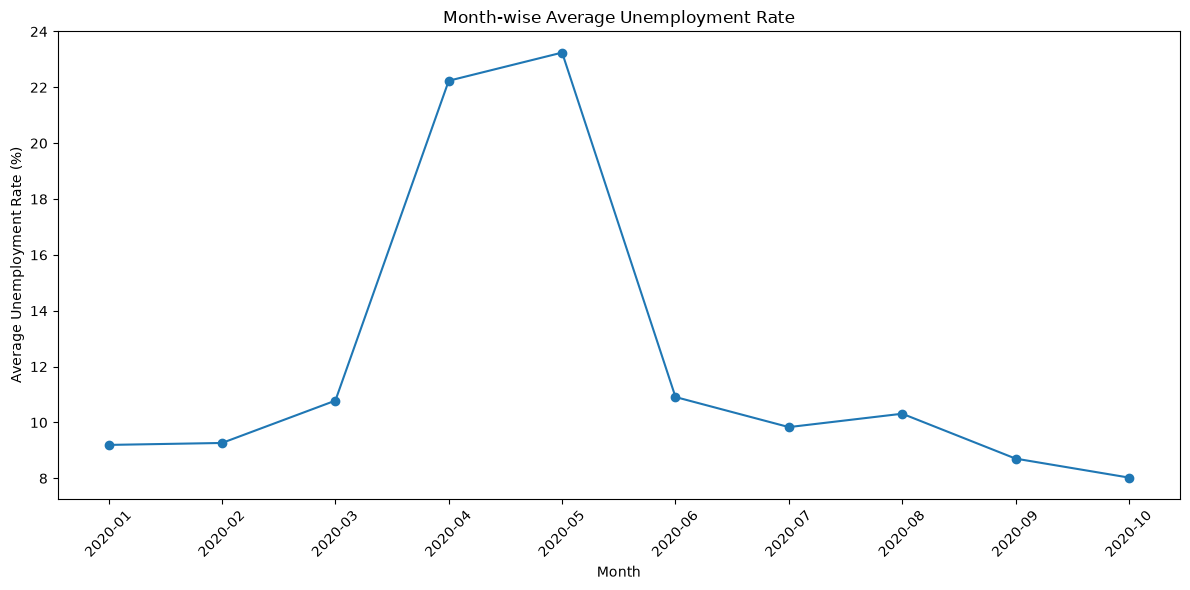

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.title('Month-wise Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The line chart shows how the average unemployment rate changed month by month.
The trend helps us understand the changes in unemployment levels over the
observed period.

## 6. Time-Series Analysis

### 6.1 Unemployment Rate Over Time for Major States

In [15]:
print("Available Regions/States:")
print(df['Region'].unique())

Available Regions/States:
<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal']
Length: 27, dtype: str


In [16]:
print(df['Region'].unique())

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal']
Length: 27, dtype: str


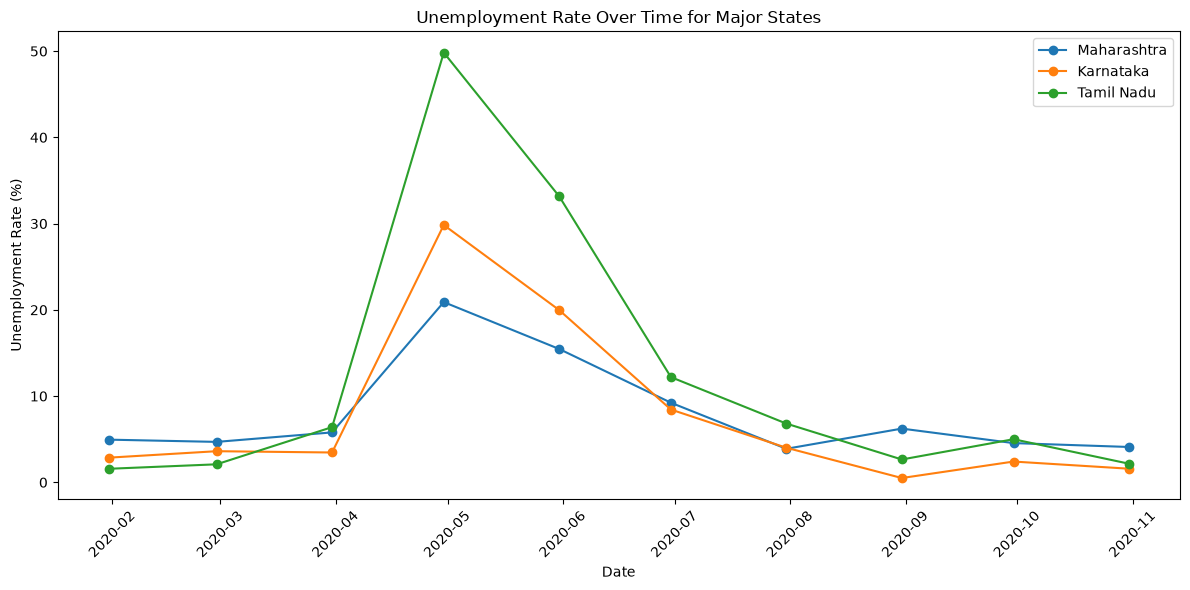

In [17]:
states = ['Maharashtra', 'Karnataka', 'Tamil Nadu']

plt.figure(figsize=(12, 6))

for state in states:
    state_data = df[df['Region'] == state].sort_values('Date')
    plt.plot(
        state_data['Date'],
        state_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=state
    )

plt.title('Unemployment Rate Over Time for Major States')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The time-series chart shows the changes in unemployment rates over time
for Maharashtra, Karnataka, and Tamil Nadu. The chart helps compare the
unemployment trends of these three states during the observed period.

## 7. Top 10 States with Highest Average Unemployment Rate

In [18]:
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'] \
         .mean() \
         .sort_values(ascending=False) \
         .head(10)

print("Top 10 States/Regions with Highest Average Unemployment Rate:")
print(top10)

Top 10 States/Regions with Highest Average Unemployment Rate:
Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64


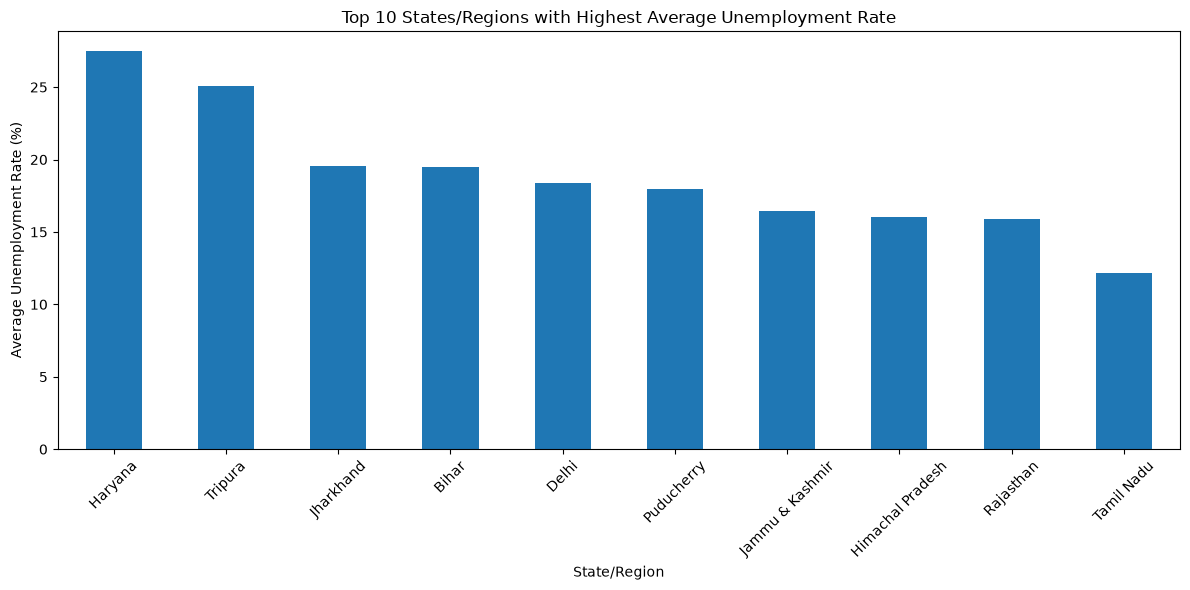

In [19]:
plt.figure(figsize=(12, 6))

top10.plot(kind='bar')

plt.title('Top 10 States/Regions with Highest Average Unemployment Rate')
plt.xlabel('State/Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The bar chart displays the 10 states/regions with the highest average
unemployment rates in the dataset. It provides a clear comparison of
average unemployment levels among the top 10 regions.

## 8. Correlation Analysis

### 8.1 Correlation Between Unemployment, Employment and Labour Participation

In [20]:
corr = df[['Estimated Unemployment Rate (%)',
           'Estimated Employed',
           'Estimated Labour Participation Rate (%)']].corr()

print("Correlation Matrix:")
print(corr)

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.245176   
Estimated Labour Participation Rate (%)                        -0.073540   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.245176   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.047948   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                        -0.073540  
Estimated Employed                                                     -0.047948  
Estimated Labour Participation Rate (%)                                 1.000000  


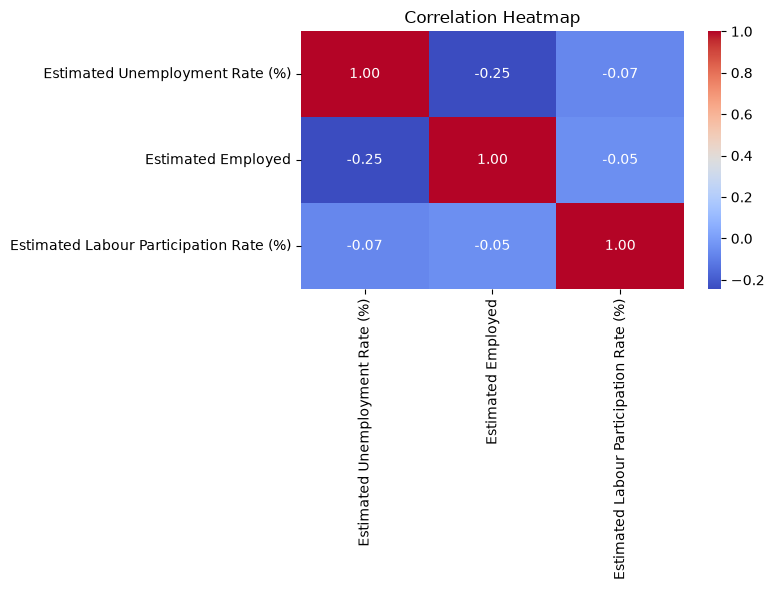

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between unemployment rate,
employment level, and labour participation rate. The correlation values
help identify whether the variables have positive or negative relationships
with each other.

## 9. Pre-COVID vs Post-COVID Analysis

### 9.1 Splitting the Data by Date

In [22]:
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 52
Post-COVID records: 215


### 9.2 Average Unemployment Rate Comparison

In [23]:
pre_covid_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_avg = post_covid['Estimated Unemployment Rate (%)'].mean()

print("Pre-COVID Average Unemployment Rate:",
      round(pre_covid_avg, 2), "%")

print("Post-COVID Average Unemployment Rate:",
      round(post_covid_avg, 2), "%")

Pre-COVID Average Unemployment Rate: 9.23 %
Post-COVID Average Unemployment Rate: 12.96 %


### 9.3 COVID-19 Impact Visualization

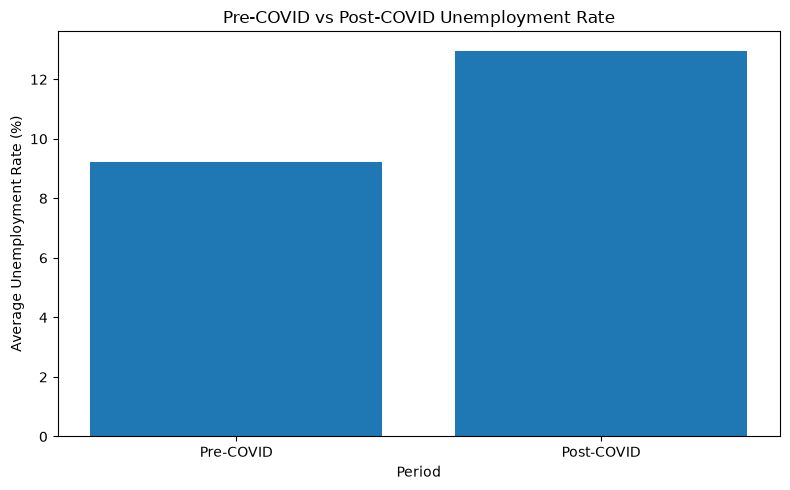

In [24]:
comparison = pd.DataFrame({
    'Period': ['Pre-COVID', 'Post-COVID'],
    'Average Unemployment Rate (%)': [pre_covid_avg, post_covid_avg]
})

plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Period'],
    comparison['Average Unemployment Rate (%)']
)

plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

### Observation

The comparison chart shows the difference in average unemployment rates
between the pre-COVID and post-COVID periods. It helps visualize the
change in unemployment levels after the beginning of the COVID-19 period.

## 10. Key Findings


- The analysis shows that unemployment rates vary across different regions
  of India.

- The month-wise analysis shows changes in the average unemployment rate
  during the observed period.

- The time-series analysis shows that unemployment rates changed over time
  for Maharashtra, Karnataka, and Tamil Nadu.

- The top 10 analysis highlights the regions with the highest average
  unemployment rates in the dataset.

- The correlation analysis shows the relationship between unemployment rate,
  employment level, and labour participation rate.

- The pre-COVID and post-COVID comparison shows a difference in average
  unemployment rates between the two periods.

- Data visualization helped make regional, monthly, and COVID-19 related
  unemployment patterns easier to understand.

## 11. Conclusion

This analysis provided an overview of unemployment trends in India using
data from different regions and time periods. Exploratory data analysis
was used to compare regional unemployment rates, study month-wise trends,
and examine unemployment patterns across selected states.

The correlation analysis helped understand the relationships between
unemployment rate, employment level, and labour participation rate.
The pre-COVID and post-COVID comparison also provided a clear view of
changes in unemployment levels during the observed period.

Overall, the analysis demonstrates how Python, Pandas, Matplotlib, and
Seaborn can be used to clean, analyze, visualize, and interpret
real-world unemployment data.

## 12. Dataset Source

The dataset used in this project is "Unemployment in India", obtained
from Kaggle.

Source: Kaggle — Unemployment in India

Dataset file: `Unemployment_Rate_upto_11_2020.csv`